# TRPO
이 튜토리얼은 **TRPO (Trust Region Policy Optimization)** 알고리즘을 구현하는 방법을 안내한다.

**TRPO**는 PPO의 기반이 되는 알고리즘으로, 정책이 업데이트될 때 너무 급격하게 변하지 않도록 **KL Divergence**를 제약 조건(Trust Region)으로 둔다. 이를 풀기 위해 **2차 미분 정보(Hessian)**를 근사하여 사용하며, **켤레 기울기법(Conjugate Gradient)**과 **라인 서치(Line Search)**를 통해 최적의 업데이트 스텝을 찾는다. 수식적으로 복잡하지만 강화학습 이론에서 매우 중요한 위치를 차지한다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 사용하여 구현하며, 환경은 `LunarLanderContinuous-v2`를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [7]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [8]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [9]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. 수학적 유틸리티 함수 (Mathematical Utilities)

TRPO 구현을 위해 필요한 수학적 연산 함수들이다.

* `flat_grad`: 네트워크 파라미터의 기울기(Gradient)를 1차원 벡터로 평탄화한다.
* `conjugate_gradient`:  형태의 선형 방정식을 근사적으로 푼다. TRPO에서는  (는 헤시안, 는 기울기)를 풀어 업데이트 방향을 찾는다.

In [10]:
def flat_grad(grads, params):
    """기울기를 1차원 벡터로 평탄화"""
    grad_flatten = []
    for p in params:
        if p.grad is None:
            grad_flatten.append(torch.zeros(p.numel()).to(device))
        else:
            grad_flatten.append(p.grad.data.view(-1))
    return torch.cat(grad_flatten)

def flat_grad(grads, params):
    """
    기울기 튜플을 받아 그래프를 유지하며 1차원 벡터로 평탄화합니다.
    .data를 사용하면 2차 미분이 불가능해지므로 주의해야 합니다.
    """
    grad_flatten = []
    for grad, p in zip(grads, params):
        if grad is None:
            grad_flatten.append(torch.zeros(p.numel(), device=device))
        else:
            # .data를 쓰지 않고 view만 사용하여 그래프 연결을 유지합니다.
            grad_flatten.append(grad.reshape(-1))
    return torch.cat(grad_flatten)

def update_model(model, new_params):
    """평탄화된 파라미터를 다시 모델에 주입"""
    index = 0
    for param in model.parameters():
        param_length = param.numel()
        new_param = new_params[index: index + param_length]
        new_param = new_param.view(param.size())
        param.data.copy_(new_param)
        index += param_length

def conjugate_gradient(f_Ax, b, cg_iters=10, residual_tol=1e-10):
    """
    켤레 기울기법 (Conjugate Gradient Method)
    Ax = b 에서 x를 근사적으로 구함 (여기서 A는 Fisher Information Matrix)
    """
    p = b.clone()
    r = b.clone()
    x = torch.zeros_like(b)
    rdotr = torch.dot(r, r)

    for _ in range(cg_iters):
        z = f_Ax(p)
        v = rdotr / (torch.dot(p, z) + 1e-8)
        x += v * p
        r -= v * z
        newrdotr = torch.dot(r, r)
        mu = newrdotr / (rdotr + 1e-8)
        p = r + mu * p
        rdotr = newrdotr

        if rdotr < residual_tol:
            break
    return x

### 5. Actor & Critic 네트워크 생성 (Create Actor & Critic Networks)

PPO와 동일하게 Actor(정책)와 Critic(가치) 네트워크를 정의한다.

In [11]:
class Actor(nn.Module):
    def __init__(self, obs_size, hidden_size, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        self.mean_layer = nn.Linear(hidden_size, action_dim)
        self.log_std = nn.Parameter(torch.zeros(1, action_dim))

    def forward(self, x):
        x = self.net(x)
        mean = self.mean_layer(x)
        std = self.log_std.exp().expand_as(mean)
        return mean, std

class Critic(nn.Module):
    def __init__(self, obs_size, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

### 6. Pytorch Wrapper 클래스 (TRPO 구현)

TRPO의 핵심 로직인 **Hessian-Vector Product**, **Conjugate Gradient**, **Line Search**가 포함된 클래스다.

* **Hessian-Vector Product (HVP)**: 거대한 헤시안 행렬()을 직접 구하지 않고, 벡터()와의 곱()만을 계산하여 메모리를 절약한다.
* **Line Search**: 계산된 방향으로 업데이트했을 때, 실제로 목적 함수가 개선되는지, 그리고 KL Divergence 제약을 만족하는지 확인하며 스텝 크기를 조절한다.

In [12]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=64,
                 gamma=0.99, gae_lambda=0.95,
                 delta=0.01, damping=0.1, cg_iters=10,
                 backtrack_iters=10, backtrack_coeff=0.8,
                 n_steps=2048):

        self.env_name = env_name
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.delta = delta              # KL Divergence 제약 상수 (Trust Region 크기)
        self.damping = damping          # 수치 안정성을 위한 댐핑 계수
        self.cg_iters = cg_iters        # CG 반복 횟수
        self.backtrack_iters = backtrack_iters # 라인 서치 반복 횟수
        self.backtrack_coeff = backtrack_coeff # 라인 서치 감쇠 비율
        self.n_steps = n_steps

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        action_dim = self.env.action_space.shape[0]

        # 네트워크 생성
        self.actor = Actor(obs_size, hidden_size, action_dim).to(device)
        self.critic = Critic(obs_size, hidden_size).to(device)

        # Critic용 최적화기 (Actor는 TRPO 로직으로 직접 업데이트)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

    def get_action(self, state):
        state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
        with torch.no_grad():
            mean, _ = self.actor(state_t)
        return mean.cpu().numpy()[0]

    def compute_gae(self, rewards, values, dones, next_value):
        """GAE 계산"""
        advantages = torch.zeros_like(rewards).to(device)
        last_gae_lam = 0

        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_non_terminal = 1.0 - 0.0
                next_val = next_value
            else:
                next_non_terminal = 1.0 - dones[t+1]
                next_val = values[t+1]

            delta = rewards[t] + self.gamma * next_val * next_non_terminal - values[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns = advantages + values
        return advantages, returns

    def fisher_vector_product(self, vector, states):
        """
        Fisher Information Matrix와 벡터의 곱 (Hv) 계산
        """
        # 1. 미분 가능하도록 출력 계산
        mean, std = self.actor(states)
        dist = Normal(mean, std)

        # 2. 고정된 Old Policy (그래프에서 분리)
        with torch.no_grad():
            mean_old, std_old = mean.detach(), std.detach()
            dist_old = Normal(mean_old, std_old)

        # 3. KL Divergence 계산
        kl = torch.distributions.kl.kl_divergence(dist_old, dist).mean()

        # 4. 1차 미분 (create_graph=True가 핵심!)
        # 여기서 grads는 텐서들의 튜플이며, 각 텐서는 grad_fn을 가집니다.
        grads = torch.autograd.grad(kl, self.actor.parameters(), create_graph=True)

        # 수정된 flat_grad 호출
        flat_grads = flat_grad(grads, self.actor.parameters())

        # 5. KL_grad * vector 내적
        # vector는 CG에서 온 상수 벡터이므로 detach 상태여도 무방합니다.
        kl_v = (flat_grads * vector).sum()

        # 6. 2차 미분 (이제 kl_v에 grad_fn이 살아있어 에러가 나지 않습니다)
        grads_2nd = torch.autograd.grad(kl_v, self.actor.parameters())
        flat_grads_2nd = flat_grad(grads_2nd, self.actor.parameters())

        return flat_grads_2nd + self.damping * vector

    def train_step(self):
        # 1. 데이터 수집 (Rollout)
        states, actions, rewards, dones, values = [], [], [], [], []

        state, _ = self.env.reset()

        for _ in range(self.n_steps):
            state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)

            with torch.no_grad():
                mean, std = self.actor(state_t)
                dist = Normal(mean, std)
                action = dist.sample()
                value = self.critic(state_t)

            action_np = action.cpu().numpy()[0]
            next_state, reward, terminated, truncated, _ = self.env.step(action_np)
            done_flag = terminated or truncated

            states.append(state_t)
            actions.append(action)
            rewards.append(reward)
            dones.append(done_flag)
            values.append(value)

            state = next_state
            if done_flag:
                state, _ = self.env.reset()

        states = torch.cat(states)
        actions = torch.cat(actions)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device)
        values = torch.cat(values).squeeze()

        with torch.no_grad():
            next_state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
            next_value = self.critic(next_state_t).squeeze()

        advantages, returns = self.compute_gae(rewards, values, dones, next_value)
        # Advantage 정규화
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 2. Critic 업데이트 (MSE Loss)
        for _ in range(10): # Critic은 여러 번 업데이트
            v_pred = self.critic(states).squeeze()
            v_loss = F.mse_loss(v_pred, returns)
            self.critic_optimizer.zero_grad()
            v_loss.backward()
            self.critic_optimizer.step()

        # 3. Actor 업데이트 (TRPO)

        # 현재 정책의 Log Probability 계산
        mean, std = self.actor(states)
        dist = Normal(mean, std)
        old_log_probs = dist.log_prob(actions).sum(dim=-1).detach()

        # Surrogate Loss 함수 정의
        def get_loss(volatile=False):
            if volatile:
                with torch.no_grad():
                    mean, std = self.actor(states)
                    dist = Normal(mean, std)
                    log_probs = dist.log_prob(actions).sum(dim=-1)
            else:
                mean, std = self.actor(states)
                dist = Normal(mean, std)
                log_probs = dist.log_prob(actions).sum(dim=-1)

            ratio = torch.exp(log_probs - old_log_probs)
            return -(ratio * advantages).mean()

        # 1차 미분 (Policy Gradient) 계산
        loss = get_loss()
        grads = torch.autograd.grad(loss, self.actor.parameters())
        loss_grad = flat_grad(grads, self.actor.parameters())

        # Conjugate Gradient로 Search Direction(x) 계산: Hx = g
        # 여기서 Fisher Vector Product 함수를 인자로 넘김
        fvp = lambda v: self.fisher_vector_product(v, states)
        step_dir = conjugate_gradient(fvp, -loss_grad, self.cg_iters)

        # Step Size 계산 (Lagrange Multiplier)
        # beta = sqrt(2 * delta / x^T H x)
        shs = 0.5 * (step_dir * fvp(step_dir)).sum(0, keepdim=True)
        max_step = torch.sqrt(self.delta / shs[0])
        full_step = step_dir * max_step

        # Line Search (Backtracking)
        old_params = flat_params(self.actor)
        expected_improve = -(loss_grad * full_step).sum()

        flag = False
        for i in range(self.backtrack_iters):
            # Step 크기를 줄여가며 시도
            step_frac = self.backtrack_coeff ** i
            new_params = old_params + step_frac * full_step
            update_model(self.actor, new_params)

            # 조건 확인: Loss가 개선되었는가? KL 제약을 만족하는가?
            new_loss = get_loss(volatile=True)

            # KL 계산
            with torch.no_grad():
                mean_new, std_new = self.actor(states)
                dist_new = Normal(mean_new, std_new)
                mean_old, std_old = mean.detach(), std.detach()
                dist_old = Normal(mean_old, std_old)
                kl = torch.distributions.kl.kl_divergence(dist_old, dist_new).mean()

            # Actual improvement > 0 (Minimizing negative loss)
            loss_improve = loss - new_loss

            if kl <= self.delta * 1.5 and loss_improve > 0:
                flag = True
                break

        # 조건을 만족하지 못하면 업데이트 취소
        if not flag:
            update_model(self.actor, old_params)

        return returns.mean().item()

    def run_training(self, max_timesteps=200000):
        total_steps = 0
        rewards_history = []

        while total_steps < max_timesteps:
            mean_return = self.train_step()
            total_steps += self.n_steps
            rewards_history.append(mean_return)

            if total_steps % (self.n_steps * 5) == 0:
                print(f"Steps: {total_steps}, Mean Return: {mean_return:.2f}")

        return rewards_history

    def save_video(self, filename="trpo_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False

        while not done:
            action = self.get_action(state)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

TRPO 에이전트를 생성하고 `LunarLanderContinuous-v3` 환경에서 학습을 시작한다. TRPO는 계산 비용이 높지만, 업데이트가 매우 안정적인 특성이 있다.

In [13]:
# TRPO 모델 생성
agent = PytorchWrapper(
    'LunarLanderContinuous-v3',
    hidden_size=128,
    gamma=0.99,
    delta=0.01, # KL Constraint
    n_steps=2048
)

# 학습 시작
print("TRPO (Trust Region Policy Optimization) 학습을 시작한다...")
history = agent.run_training(max_timesteps=200000)
print("학습 완료.")

TRPO (Trust Region Policy Optimization) 학습을 시작한다...
Steps: 10240, Mean Return: -5.22
Steps: 20480, Mean Return: 1.66
Steps: 30720, Mean Return: 15.75
Steps: 40960, Mean Return: 10.29
Steps: 51200, Mean Return: 7.48
Steps: 61440, Mean Return: 7.10
Steps: 71680, Mean Return: 1.42
Steps: 81920, Mean Return: -4.45
Steps: 92160, Mean Return: -1.16
Steps: 102400, Mean Return: 0.67
Steps: 112640, Mean Return: -1.86
Steps: 122880, Mean Return: -8.30
Steps: 133120, Mean Return: -7.61
Steps: 143360, Mean Return: -5.84
Steps: 153600, Mean Return: -6.06
Steps: 163840, Mean Return: -4.94
Steps: 174080, Mean Return: -5.23
Steps: 184320, Mean Return: -12.66
Steps: 194560, Mean Return: -10.99
학습 완료.


### 8. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

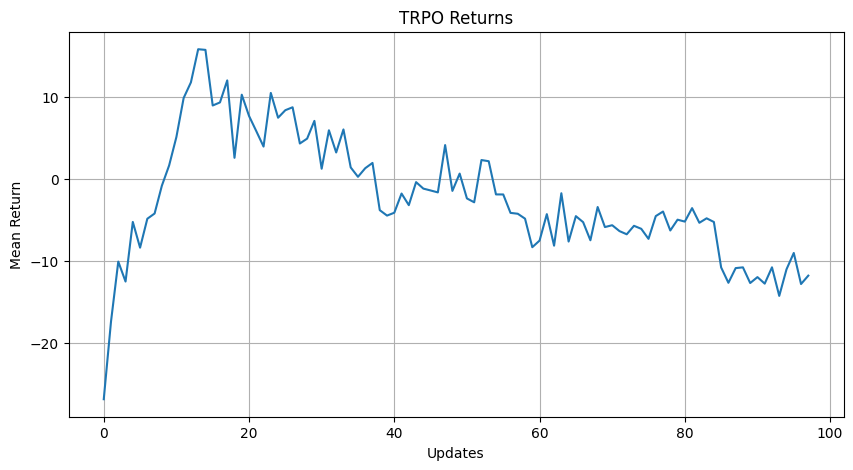

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [14]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("TRPO Returns")
plt.xlabel("Updates")
plt.ylabel("Mean Return")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("trpo")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")